In [66]:
import pandas as pd

df = pd.read_csv("../../results/week6/proactive_predictions.csv")

false_negatives = df[
    (df["Actual"] == 1) &
    (df["Predicted"] == 0)
]

false_negatives

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Actual,Predicted
17,3,112,74,30,0,31.6,0.197,25,1,1,0
18,0,124,70,20,0,27.4,0.254,36,1,1,0
24,2,102,86,36,120,45.5,0.127,23,1,1,0
45,5,0,80,32,0,41.0,0.346,37,1,1,0
84,2,155,74,17,96,26.6,0.433,27,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1891,6,195,70,0,0,30.9,0.328,31,1,1,0
1892,9,156,86,0,0,24.8,0.230,53,1,1,0
1894,3,121,52,0,0,36.0,0.127,25,1,1,0
1897,0,162,76,36,0,49.6,0.364,26,1,1,0


In [67]:
false_negatives.to_csv(
    "../../results/week6/false_negative_patients.csv",
    index=False
)

In [68]:
false_negatives.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,359.0,3.980501,3.339648,0.000,1.0000,3.000,6.000,14.00
Glucose,359.0,137.991643,37.659789,0.000,116.0000,135.000,167.000,199.00
BloodPressure,359.0,73.169916,17.240546,0.000,68.0000,74.000,82.000,106.00
SkinThickness,359.0,24.000000,17.436557,0.000,0.0000,29.000,36.000,99.00
Insulin,359.0,90.977716,123.441930,0.000,0.0000,0.000,165.000,600.00
BMI,359.0,34.838162,5.659680,23.400,31.2000,34.300,37.800,59.40
DiabetesPedigreeFunction,359.0,0.491752,0.328228,0.088,0.2405,0.376,0.682,2.42
Age,359.0,35.150418,10.745907,21.000,27.0000,33.000,43.000,70.00
Outcome,359.0,1.000000,0.000000,1.000,1.0000,1.000,1.000,1.00
Actual,359.0,1.000000,0.000000,1.000,1.0000,1.000,1.000,1.00


In [69]:
diabetic = df[df["Actual"] == 1]

comparison = pd.DataFrame({
    "False Negative Mean": false_negatives.mean(numeric_only=True),
    "All Diabetic Mean": diabetic.mean(numeric_only=True)
})

comparison

,False Negative Mean,All Diabetic Mean
Pregnancies,3.980501,4.655462
Glucose,137.991643,142.789916
BloodPressure,73.169916,70.336134
SkinThickness,24.000000,23.285714
Insulin,90.977716,100.596639
BMI,34.838162,34.821849
DiabetesPedigreeFunction,0.491752,0.539605
Age,35.150418,36.806723
Outcome,1.000000,1.000000
Actual,1.000000,1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../results/week6/proactive_predictions.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1900, 11)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            3      150             76              0        0  21.0   
1            2      120             76             37      105  39.7   
2           10      161             68             23      132  25.5   
3            0      137             68             14      148  24.8   
4            0      128             68             19      180  30.5   

   DiabetesPedigreeFunction  Age  Outcome  Actual  Predicted  
0                     0.207   37        0       0          1  
1                     0.215   29        0       0          0  
2                     0.326   47        1       1          1  
3                     0.143   21        0       0          0  
4                     1.391   25        1       1          1  


In [71]:
print("="*50)
print("Prediction Summary")
print("="*50)

print("Total Samples:", len(df))
print("Actual Diabetic Patients:", (df["Actual"] == 1).sum())
print("Predicted Diabetic Patients:", (df["Predicted"] == 1).sum())


Prediction Summary
Total Samples: 1900
Actual Diabetic Patients: 595
Predicted Diabetic Patients: 510


In [72]:
tp = df[(df["Actual"] == 1) & (df["Predicted"] == 1)]
fn = df[(df["Actual"] == 1) & (df["Predicted"] == 0)]
fp = df[(df["Actual"] == 0) & (df["Predicted"] == 1)]
tn = df[(df["Actual"] == 0) & (df["Predicted"] == 0)]

print("True Positives :", len(tp))
print("False Negatives:", len(fn))
print("False Positives:", len(fp))
print("True Negatives :", len(tn))

True Positives : 236
False Negatives: 359
False Positives: 274
True Negatives : 1031


In [73]:
features = [
    "Glucose",
    "BMI",
    "Age",
    "Insulin",
    "BloodPressure",
    "Pregnancies"
]

comparison = pd.DataFrame({
    "True Positive Mean": tp[features].mean(),
    "False Negative Mean": fn[features].mean()
})

comparison["Difference"] = (
    comparison["False Negative Mean"] -
    comparison["True Positive Mean"]
)

print(comparison.round(2))

               True Positive Mean  False Negative Mean  Difference
Glucose                    150.09               137.99      -12.10
BMI                         34.80                34.84        0.04
Age                         39.33                35.15       -4.18
Insulin                    115.23                90.98      -24.25
BloodPressure               66.03                73.17        7.14
Pregnancies                  5.68                 3.98       -1.70


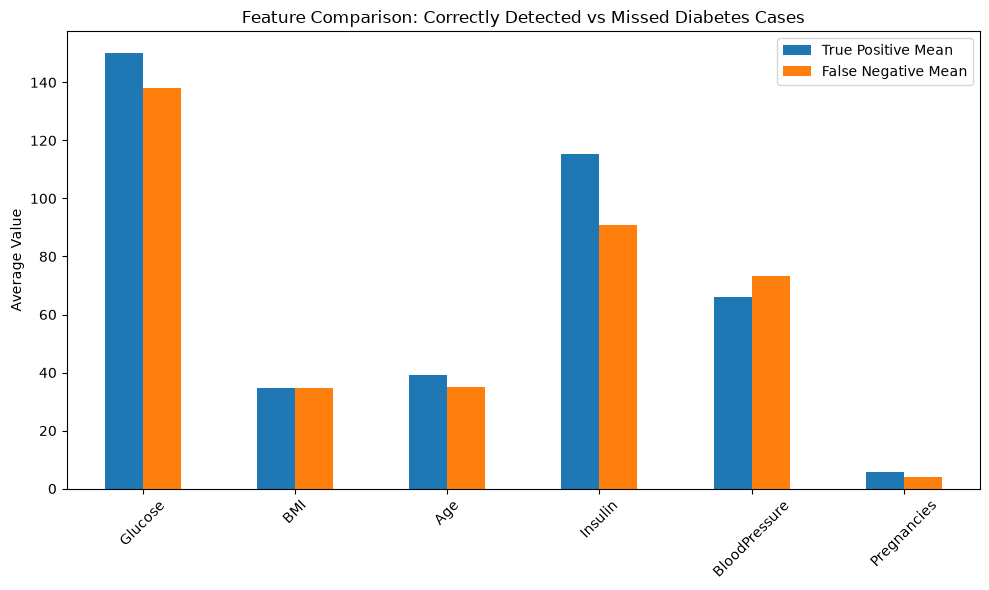

In [74]:
comparison[["True Positive Mean","False Negative Mean"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Feature Comparison: Correctly Detected vs Missed Diabetes Cases")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../../results/week6/error_analysis_feature_comparison.png")
plt.show()